Titanic Survival Prediction - ML Algorithms Comparison


Import Libraries

In [90]:
#Data 
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Sklearn preprocessing lib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, f1_score

#Sklearn Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


#warnings
import warnings
warnings.filterwarnings('ignore')


Load Datasets


In [91]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Exploratory Data Analysis

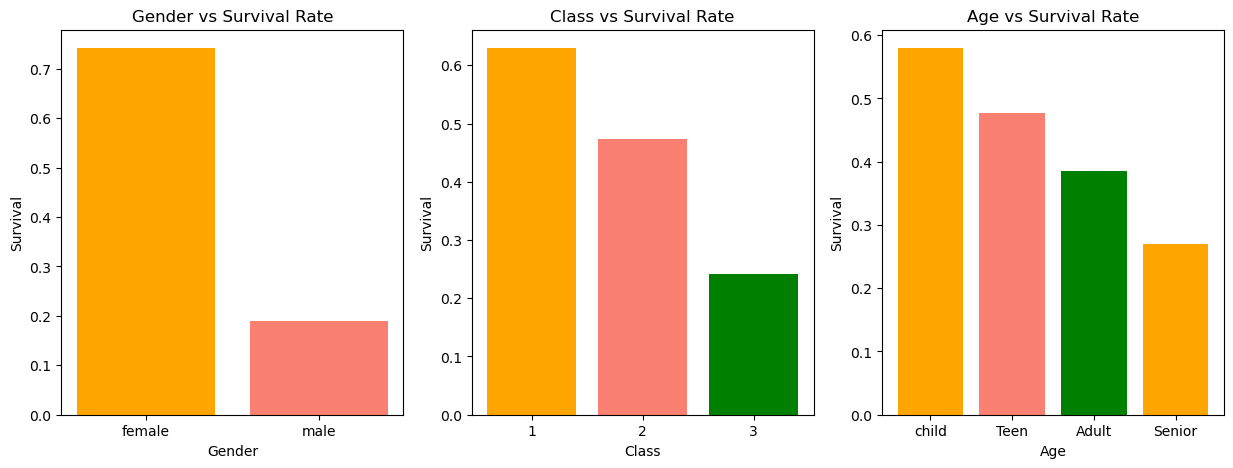

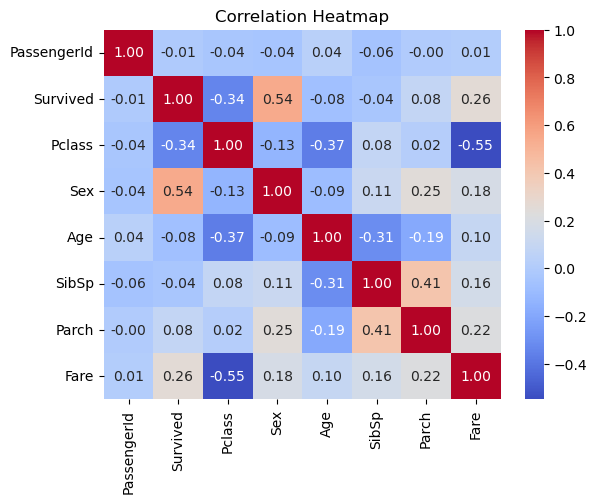

In [92]:
df.shape
# df.info()

df["Survived"].value_counts

gender_result = df.groupby('Sex')['Survived'].mean()
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
class_result = df.groupby("Pclass")['Survived'].mean()
bins = [0, 12, 17, 59, 100]
labels = ['child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_result = df.groupby('AgeGroup')['Survived'].mean()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#plot 1
axes[0].bar(gender_result.index, gender_result.values, color=['orange', 'salmon', 'green'])
axes[0].set_title("Gender vs Survival Rate")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Survival")

#plot 2
axes[1].bar(class_result.index, class_result.values, color=['orange', 'salmon', 'green'])
axes[1].set_title("Class vs Survival Rate")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Survival")
axes[1].set_xticks([1, 2, 3])

#plot 3
axes[2].bar(age_result.index, age_result.values, color=['orange', 'salmon', 'green'])
axes[2].set_title("Age vs Survival Rate")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Survival")


plt.figure()
corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()





Data PreProcessing

In [93]:
#Filling missing Values
df.drop(columns=["Cabin", "Name", "PassengerId", "Ticket"], inplace=True)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df.head()




# #Train Test Split
y = df['Survived']
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "AgeGroup", "Embarked_Q" ,"Embarked_S"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

age_median = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(age_median)
X_test['Age'] = X_test['Age'].fillna(age_median)


X_train['AgeGroup'] = X_train['AgeGroup'].cat.codes
X_test['AgeGroup'] = X_test['AgeGroup'].cat.codes


print(X_train.isnull().sum()[X_train.isnull().sum()>0])
print(X_test.isnull().sum()[X_test.isnull().sum()>0])



Series([], dtype: int64)
Series([], dtype: int64)


Model Training 

In [94]:

model1 = LogisticRegression()
model2 = KNeighborsClassifier()
model3 = DecisionTreeClassifier()
model4 = RandomForestClassifier()
model5 = SVC()

models = [model1, model2, model3, model4, model5]

results = {}
for model in models:
    name = model.__class__.__name__
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "accuracy" : accuracy_score(y_test, preds),
        "precision" : precision_score(y_test, preds),
        "recall" : recall_score(y_test, preds),
        "f1" : f1_score(y_test, preds)

    }

results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
print(results_df)

                        accuracy  precision    recall        f1
RandomForestClassifier  0.815642   0.788732  0.756757  0.772414
LogisticRegression      0.798883   0.771429  0.729730  0.750000
DecisionTreeClassifier  0.798883   0.763889  0.743243  0.753425
KNeighborsClassifier    0.692737   0.666667  0.513514  0.580153
SVC                     0.653631   0.750000  0.243243  0.367347


Model Comparison

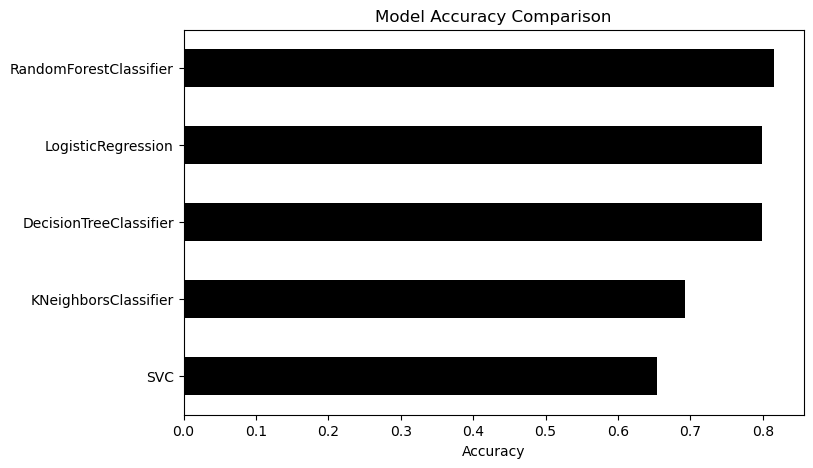

In [95]:
results_df['accuracy'].sort_values().plot(kind='barh', figsize=(8, 5), color='black')
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


Best Model Deep Dive

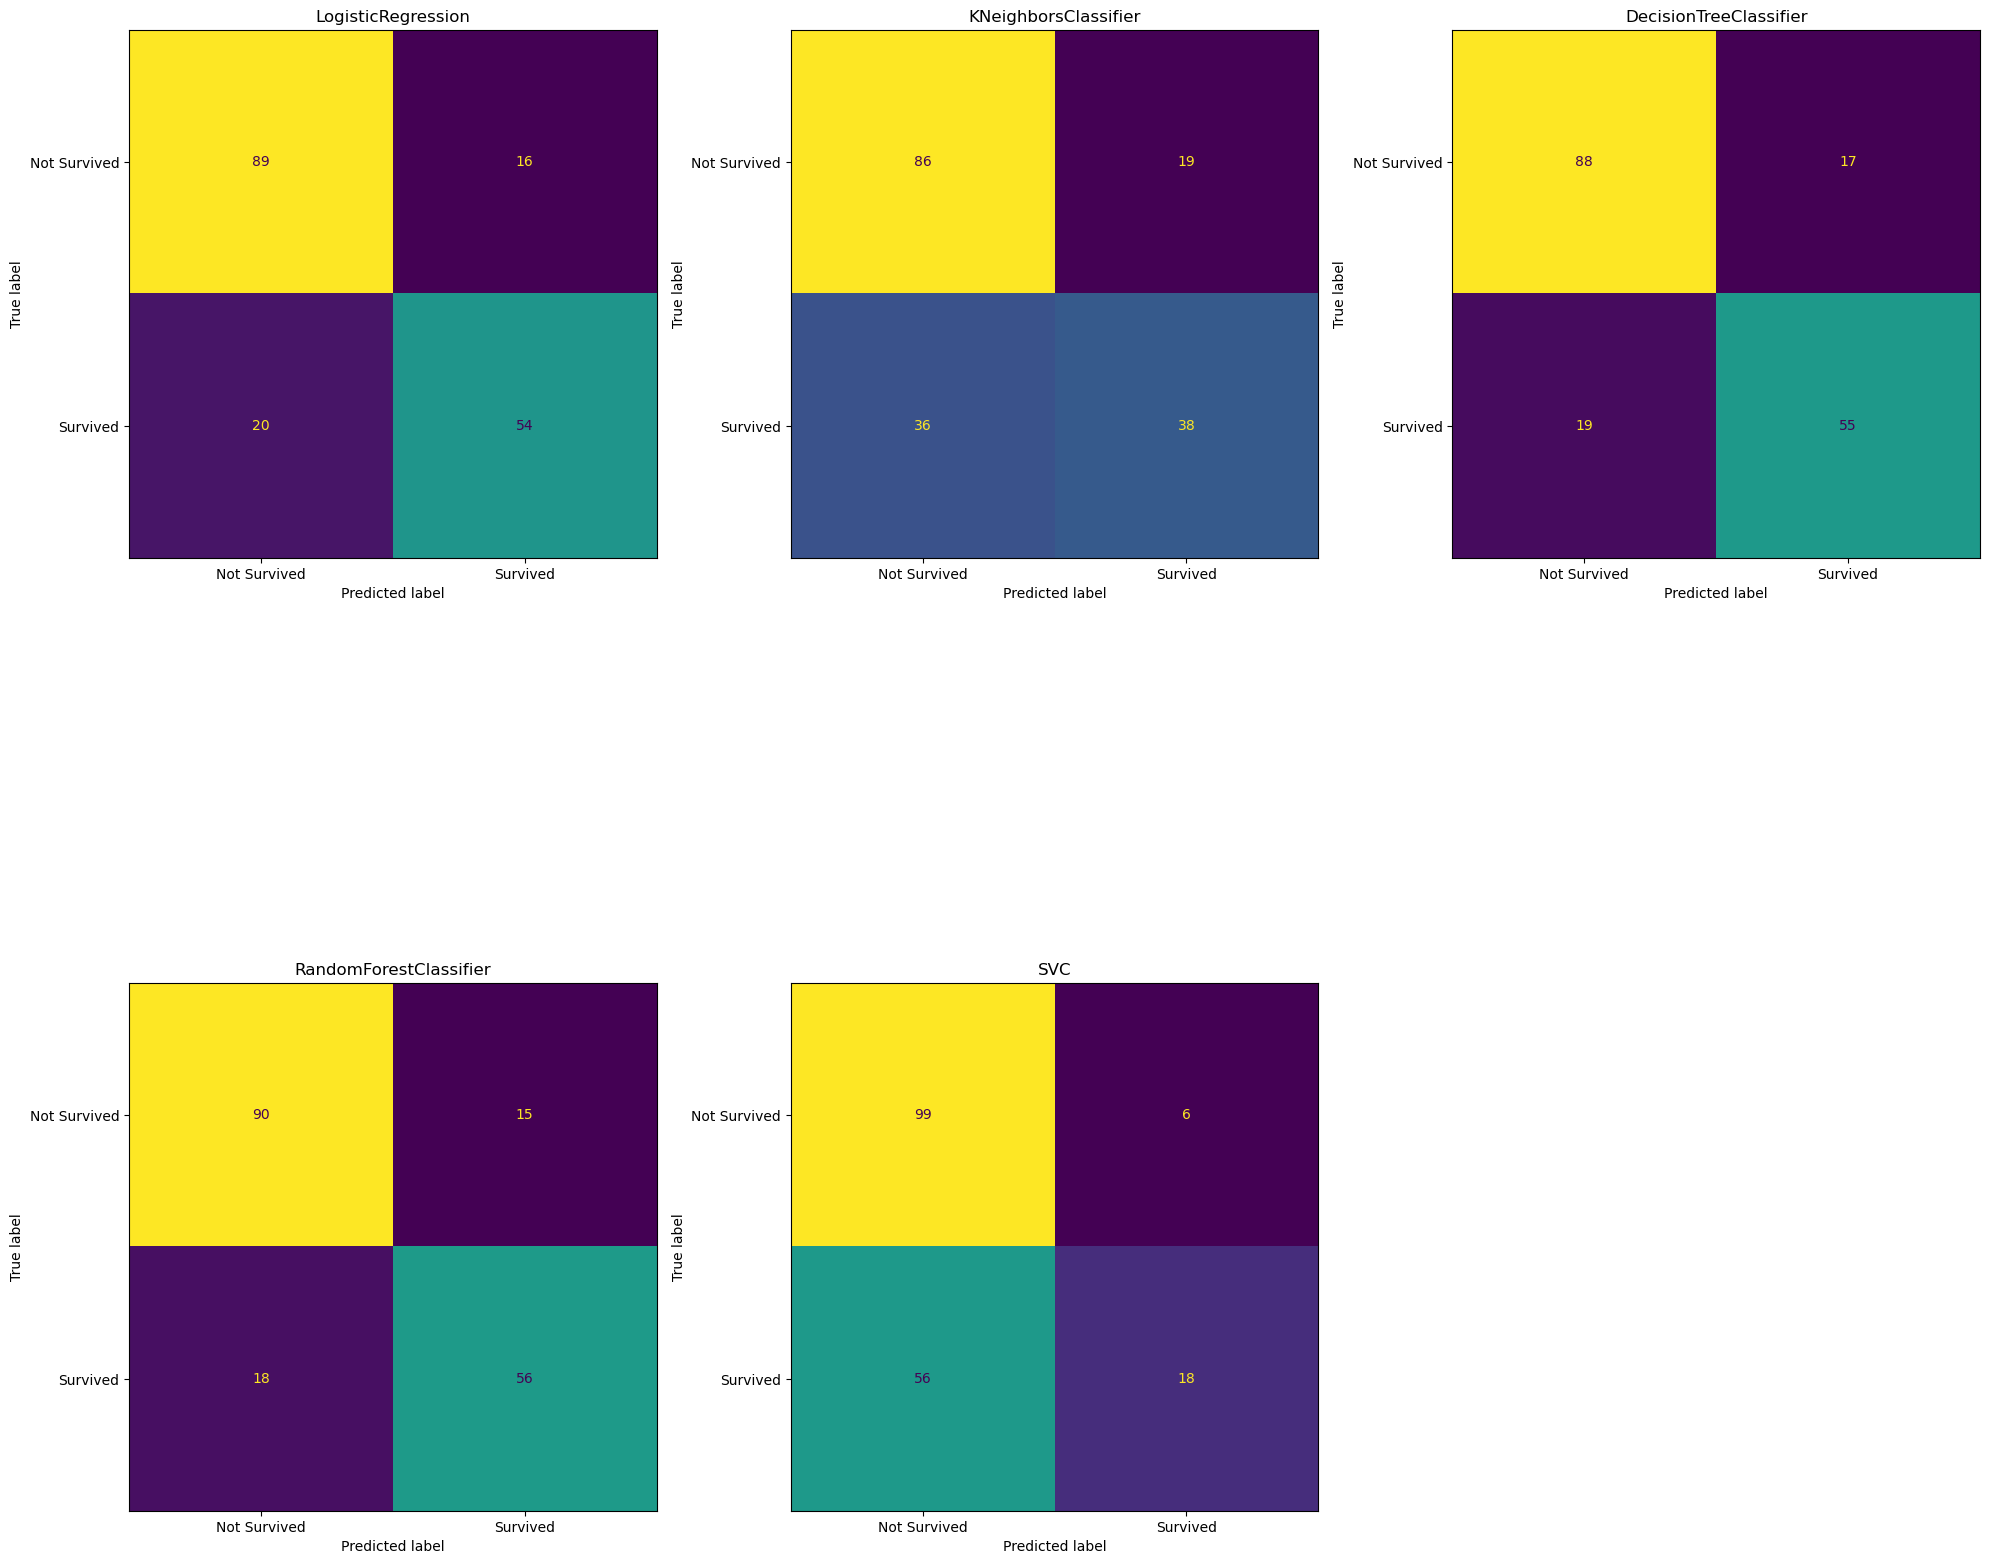

In [96]:
fig, axes = plt.subplots(2, 3, figsize =(20, 20))
axes = axes.flatten()

for i, model in enumerate(models):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived'])
    disp.plot(ax=axes[i],colorbar=False )
    axes[i].set_title(model.__class__.__name__)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


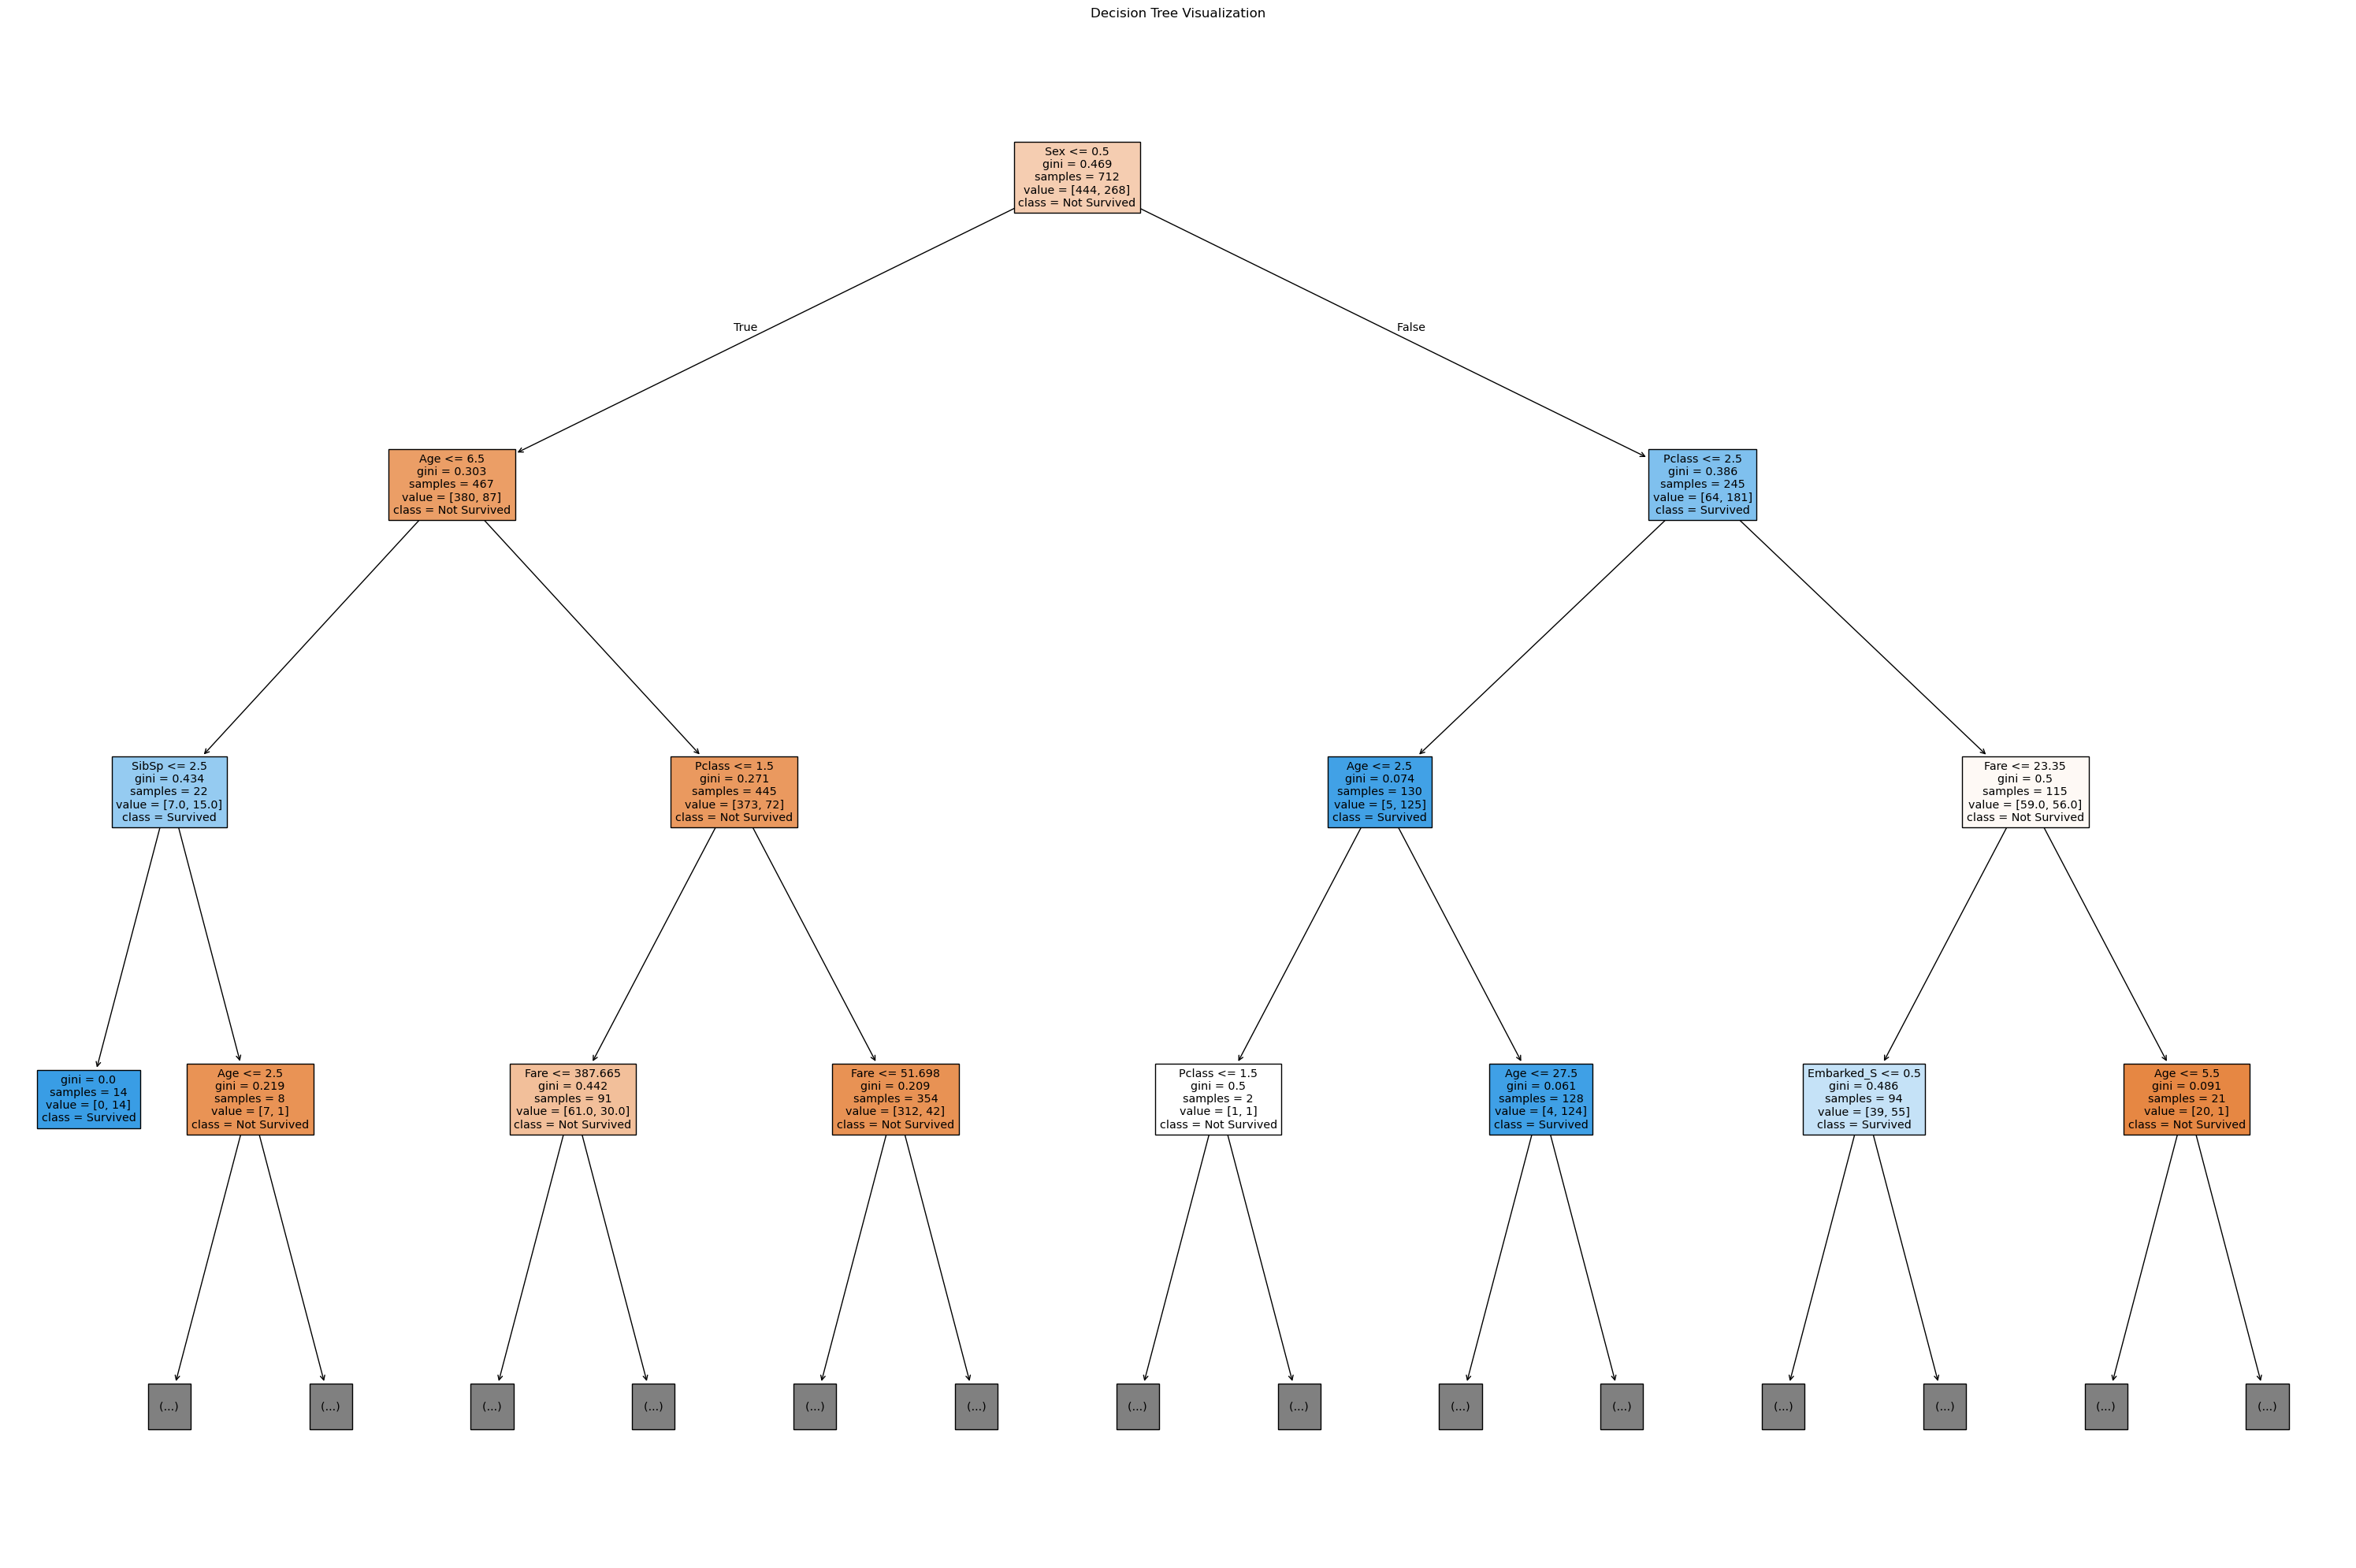

In [97]:
plt.figure(figsize=(30, 20))
plot_tree(model3,
          feature_names=X_train.columns.tolist(), 
          class_names = ["Not Survived", 'Survived'],
          filled=True, 
          max_depth=3)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

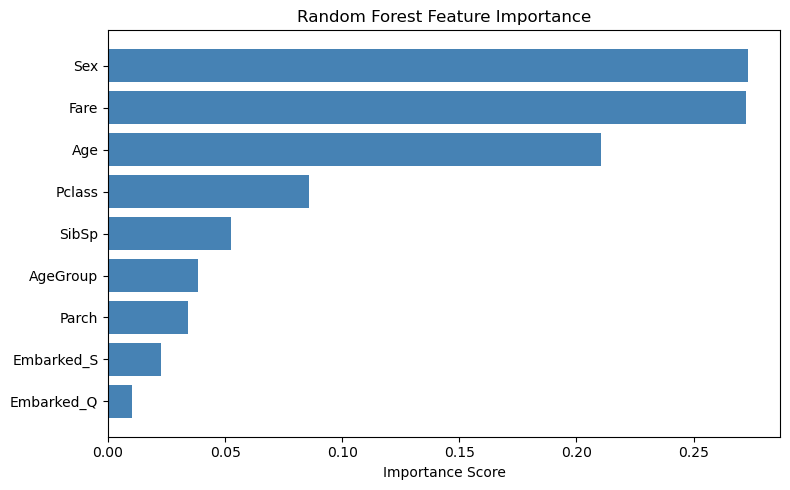

In [98]:
importances = model4.feature_importances_
features = X_train.columns
sorted_idx = importances.argsort()

plt.figure(figsize=(8, 5))
plt.barh(features[sorted_idx], importances[sorted_idx], color="steelblue")
plt.xlabel('Importance Score')
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()